# MSE Per Subject Analysis - Weighted vs Unweighted
Calculate MSE for every subject on validation and test sets using 256-dimensional latent vectors

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
from tqdm.auto import tqdm
import seaborn as sns
from scipy import stats

import importlib
import models.autoencoder.bottleneck_models
importlib.reload(models.autoencoder.bottleneck_models)

from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.autoencoder.bottleneck_models import (
    BottleneckEncoder,
    ComplexBottleneckDeconvDecoder,
    BottleneckAE,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Configuration

In [2]:
root_dir = Path(".")
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 1
latent_dim = 256
unweighted_output_dir = "output/Experiments/BottleneckDeconvTraining"
weighted_output_dir = "output/Experiments/BottleneckDeconvWeightedTraining"
mse_output_dir = "output/Experiments/MSEPerSubject"

os.makedirs(mse_output_dir, exist_ok=True)
print(f"Output directory: {mse_output_dir}")

Output directory: output/Experiments/MSEPerSubject


## Load Data

In [3]:
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files")

print("Generating dataframe...")
df = generate_dataframe(included_files)

print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    df, batch_size=batch_size, train_split=0.8, 
    on_demand=True, mask_path=mask_path,
    num_workers=0
)

print(f"Validation subjects: {len(val_loader.dataset)}")
print(f"Train subjects: {len(train_loader.dataset)}")

Found 2976 valid files
Generating dataframe...
Creating dataloaders...

Training set distribution:
label
PD         2035
Control     235
SWEDD       110
Name: count, dtype: int64

Validation set distribution:
label
PD         510
Control     59
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2380 file paths are valid
✅ Brain mask loaded successfully
✅ All 596 file paths are valid
Validation subjects: 596
Train subjects: 2380


## Build Model

In [4]:
target_shape = (64, 128, 128)

def build_model(latent_dim=256):
    model = BottleneckAE(
        BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=(1,1,1)),
        ComplexBottleneckDeconvDecoder(latent_dim=latent_dim, target_shape=target_shape),
    )
    return model.to(device)

## Load Models

In [5]:
model_name = f"deconv_lat{latent_dim}"
checkpoint_path = os.path.join(unweighted_output_dir, model_name, f"{model_name}_best.pth")

print(f"Loading unweighted model...")
unweighted_model = build_model(latent_dim=latent_dim)
unweighted_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
unweighted_model = unweighted_model.eval()
print(f"✓ Loaded")

Loading unweighted model...
✓ Loaded


In [6]:
weighted_model_name = f"deconv_weighted_lat{latent_dim}"
weighted_checkpoint_path = os.path.join(weighted_output_dir, weighted_model_name, f"{weighted_model_name}_best.pth")

print(f"Loading weighted model...")
weighted_model = build_model(latent_dim=latent_dim)
weighted_model.load_state_dict(torch.load(weighted_checkpoint_path, map_location=device))
weighted_model = weighted_model.eval()
print(f"✓ Loaded")

Loading weighted model...
✓ Loaded


## Calculate MSE - Validation Set

In [7]:
val_mse_results = []

print(f"Processing {len(val_loader)} validation subjects...")
with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(val_loader, desc="Validation")):
        inp = batch['volume'].to(device)
        label = batch['label'][0]
        
        unweighted_recon = unweighted_model(inp)
        weighted_recon = weighted_model(inp)
        
        unweighted_mse = nn.MSELoss()(unweighted_recon, inp).item()
        weighted_mse = nn.MSELoss()(weighted_recon, inp).item()
        
        val_mse_results.append({
            'Subject': f"Val_{batch_idx}",
            'Label': label,
            'Dataset': 'Validation',
            'Unweighted MSE': unweighted_mse,
            'Weighted MSE': weighted_mse,
            'MSE Difference': weighted_mse - unweighted_mse,
        })

val_df = pd.DataFrame(val_mse_results)
print(f"\nValidation set statistics:")
print(val_df[['Label', 'Unweighted MSE', 'Weighted MSE']].groupby('Label').describe())

Processing 596 validation subjects...


Validation:   0%|          | 0/596 [00:00<?, ?it/s]


Validation set statistics:
        Unweighted MSE                                                    \
                 count      mean       std       min       25%       50%   
Label                                                                      
Control           59.0  0.004189  0.001232  0.002185  0.003142  0.003996   
PD               510.0  0.003593  0.002426  0.001775  0.002752  0.003255   
SWEDD             27.0  0.003908  0.001906  0.002537  0.002876  0.003229   

                            Weighted MSE                                \
              75%       max        count      mean       std       min   
Label                                                                    
Control  0.004985  0.007519         59.0  0.005011  0.001312  0.002941   
PD       0.003894  0.052047        510.0  0.004372  0.002155  0.002388   
SWEDD    0.004164  0.011582         27.0  0.004752  0.002156  0.003234   

                                                 
              25%   

## Calculate MSE - Test Set

In [8]:
test_mse_results = []

print(f"Processing {len(train_loader)} test subjects...")
with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(train_loader, desc="Test")):
        inp = batch['volume'].to(device)
        label = batch['label'][0]
        
        unweighted_recon = unweighted_model(inp)
        weighted_recon = weighted_model(inp)
        
        unweighted_mse = nn.MSELoss()(unweighted_recon, inp).item()
        weighted_mse = nn.MSELoss()(weighted_recon, inp).item()
        
        test_mse_results.append({
            'Subject': f"Test_{batch_idx}",
            'Label': label,
            'Dataset': 'Test',
            'Unweighted MSE': unweighted_mse,
            'Weighted MSE': weighted_mse,
            'MSE Difference': weighted_mse - unweighted_mse,
        })

test_df = pd.DataFrame(test_mse_results)
print(f"\nTest set statistics:")
print(test_df[['Label', 'Unweighted MSE', 'Weighted MSE']].groupby('Label').describe())

Processing 2380 test subjects...


Test:   0%|          | 0/2380 [00:00<?, ?it/s]


Test set statistics:
        Unweighted MSE                                                    \
                 count      mean       std       min       25%       50%   
Label                                                                      
Control          235.0  0.003484  0.001056  0.002007  0.002763  0.003204   
PD              2035.0  0.003031  0.000884  0.001595  0.002424  0.002860   
SWEDD            110.0  0.003352  0.000929  0.001920  0.002542  0.003260   

                            Weighted MSE                                \
              75%       max        count      mean       std       min   
Label                                                                    
Control  0.003880  0.008075        235.0  0.004336  0.001135  0.002705   
PD       0.003383  0.010091       2035.0  0.003856  0.000988  0.002231   
SWEDD    0.004153  0.006469        110.0  0.004221  0.001018  0.002546   

                                                 
              25%       50

## Combine and Save Results

In [9]:
combined_df = pd.concat([val_df, test_df], ignore_index=True)
combined_df.to_csv(os.path.join(mse_output_dir, 'mse_per_subject.csv'), index=False)
print(f"Saved to {os.path.join(mse_output_dir, 'mse_per_subject.csv')}")

Saved to output/Experiments/MSEPerSubject/mse_per_subject.csv


## Outlier Detection

In [10]:
def detect_outliers_iqr(data, column, multiplier=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

for dataset in ['Validation', 'Test']:
    dataset_df = combined_df[combined_df['Dataset'] == dataset]
    
    unweighted_outliers = detect_outliers_iqr(dataset_df, 'Unweighted MSE')
    weighted_outliers = detect_outliers_iqr(dataset_df, 'Weighted MSE')
    
    print(f"\n{dataset} Set Outliers:")
    print(f"Unweighted: {unweighted_outliers.sum()} outliers")
    print(f"Weighted: {weighted_outliers.sum()} outliers")
    
    if unweighted_outliers.sum() > 0:
        print(f"\nUnweighted outliers:")
        print(dataset_df[unweighted_outliers][['Subject', 'Label', 'Unweighted MSE', 'Weighted MSE']])
    
    if weighted_outliers.sum() > 0:
        print(f"\nWeighted outliers:")
        print(dataset_df[weighted_outliers][['Subject', 'Label', 'Unweighted MSE', 'Weighted MSE']])


Validation Set Outliers:
Unweighted: 25 outliers
Weighted: 28 outliers

Unweighted outliers:
     Subject    Label  Unweighted MSE  Weighted MSE
6      Val_6       PD        0.007190      0.008189
54    Val_54       PD        0.006163      0.007000
57    Val_57  Control        0.007267      0.008838
60    Val_60       PD        0.007629      0.008098
183  Val_183       PD        0.006614      0.007412
234  Val_234       PD        0.006650      0.007555
247  Val_247  Control        0.006623      0.007640
252  Val_252  Control        0.007519      0.008261
268  Val_268       PD        0.006041      0.006902
278  Val_278    SWEDD        0.007818      0.009258
285  Val_285  Control        0.006172      0.007234
299  Val_299       PD        0.006302      0.007272
342  Val_342       PD        0.052047      0.044875
367  Val_367       PD        0.011469      0.012726
376  Val_376       PD        0.006712      0.008073
405  Val_405       PD        0.007170      0.007845
443  Val_443       PD 

## Visualizations

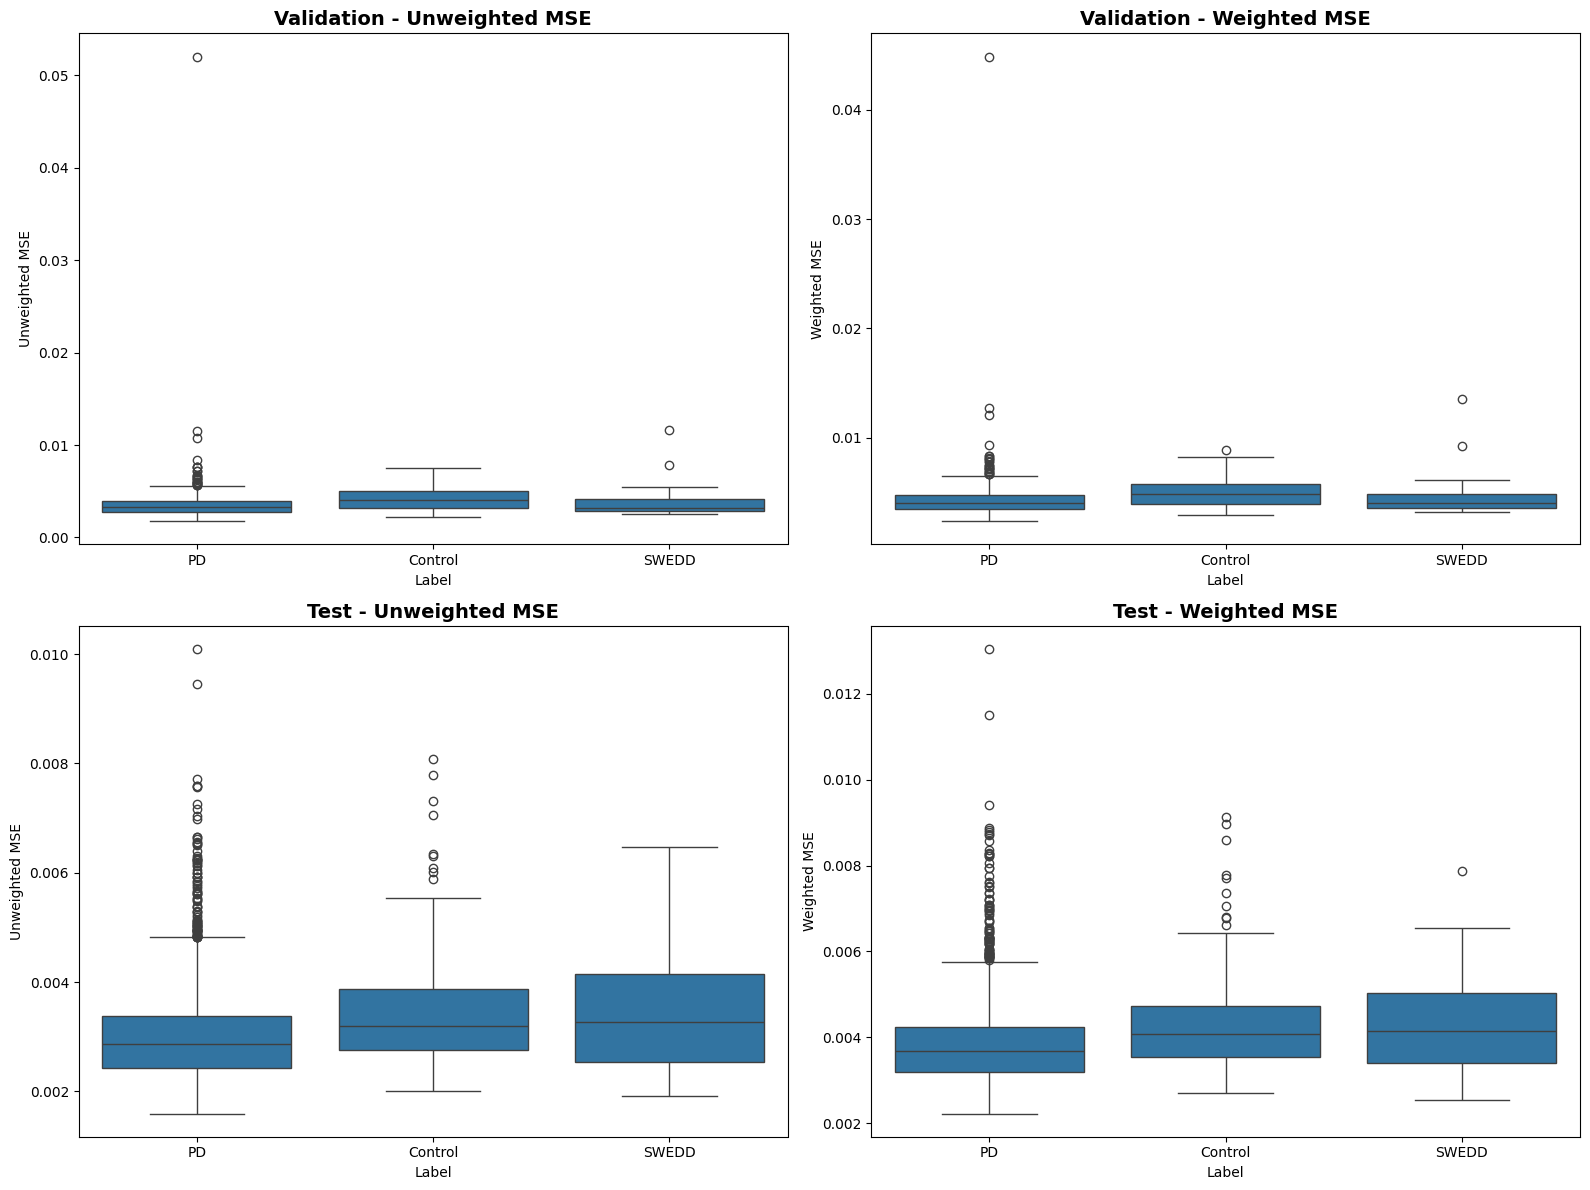

Saved to output/Experiments/MSEPerSubject/mse_boxplots.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

val_data = combined_df[combined_df['Dataset'] == 'Validation']
test_data = combined_df[combined_df['Dataset'] == 'Test']

sns.boxplot(data=val_data, x='Label', y='Unweighted MSE', ax=axes[0, 0])
axes[0, 0].set_title('Validation - Unweighted MSE', fontsize=14, fontweight='bold')

sns.boxplot(data=val_data, x='Label', y='Weighted MSE', ax=axes[0, 1])
axes[0, 1].set_title('Validation - Weighted MSE', fontsize=14, fontweight='bold')

sns.boxplot(data=test_data, x='Label', y='Unweighted MSE', ax=axes[1, 0])
axes[1, 0].set_title('Test - Unweighted MSE', fontsize=14, fontweight='bold')

sns.boxplot(data=test_data, x='Label', y='Weighted MSE', ax=axes[1, 1])
axes[1, 1].set_title('Test - Weighted MSE', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(mse_output_dir, 'mse_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {os.path.join(mse_output_dir, 'mse_boxplots.png')}")

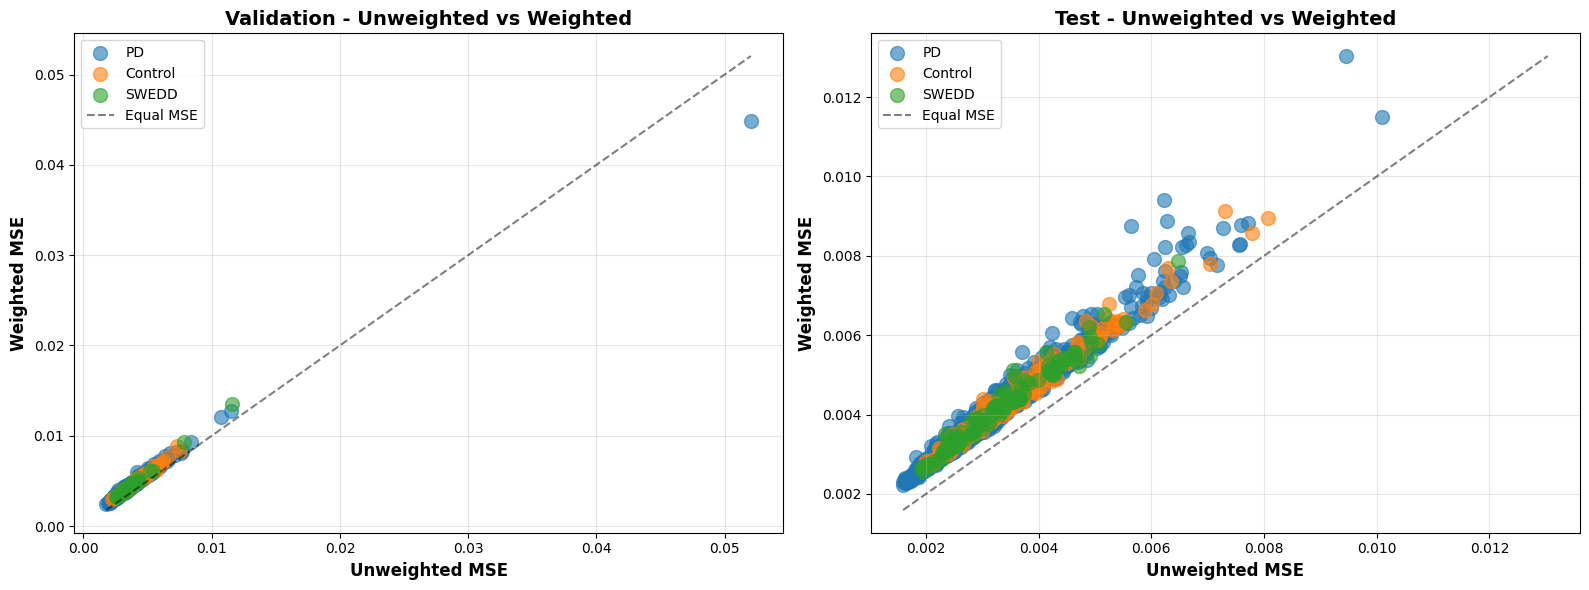

Saved to output/Experiments/MSEPerSubject/mse_scatter.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

val_data = combined_df[combined_df['Dataset'] == 'Validation']
for label in val_data['Label'].unique():
    label_data = val_data[val_data['Label'] == label]
    axes[0].scatter(label_data['Unweighted MSE'], label_data['Weighted MSE'], label=label, s=100, alpha=0.6)

min_val = min(val_data['Unweighted MSE'].min(), val_data['Weighted MSE'].min())
max_val = max(val_data['Unweighted MSE'].max(), val_data['Weighted MSE'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Equal MSE')
axes[0].set_xlabel('Unweighted MSE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Weighted MSE', fontsize=12, fontweight='bold')
axes[0].set_title('Validation - Unweighted vs Weighted', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

test_data = combined_df[combined_df['Dataset'] == 'Test']
for label in test_data['Label'].unique():
    label_data = test_data[test_data['Label'] == label]
    axes[1].scatter(label_data['Unweighted MSE'], label_data['Weighted MSE'], label=label, s=100, alpha=0.6)

min_val = min(test_data['Unweighted MSE'].min(), test_data['Weighted MSE'].min())
max_val = max(test_data['Unweighted MSE'].max(), test_data['Weighted MSE'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Equal MSE')
axes[1].set_xlabel('Unweighted MSE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Weighted MSE', fontsize=12, fontweight='bold')
axes[1].set_title('Test - Unweighted vs Weighted', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(mse_output_dir, 'mse_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {os.path.join(mse_output_dir, 'mse_scatter.png')}")

## Summary Statistics

In [13]:
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

for dataset in ['Validation', 'Test']:
    print(f"\n{dataset.upper()}:")
    dataset_df = combined_df[combined_df['Dataset'] == dataset]
    
    print(f"Total subjects: {len(dataset_df)}")
    print(f"Labels: {dataset_df['Label'].value_counts().to_dict()}")
    
    print(f"\nUnweighted MSE - Mean: {dataset_df['Unweighted MSE'].mean():.6f}, Std: {dataset_df['Unweighted MSE'].std():.6f}")
    print(f"Weighted MSE   - Mean: {dataset_df['Weighted MSE'].mean():.6f}, Std: {dataset_df['Weighted MSE'].std():.6f}")
    print(f"Difference     - Mean: {dataset_df['MSE Difference'].mean():.6f}, Std: {dataset_df['MSE Difference'].std():.6f}")


SUMMARY STATISTICS

VALIDATION:
Total subjects: 596
Labels: {'PD': 510, 'Control': 59, 'SWEDD': 27}

Unweighted MSE - Mean: 0.003666, Std: 0.002318
Weighted MSE   - Mean: 0.004452, Std: 0.002094
Difference     - Mean: 0.000786, Std: 0.000369

TEST:
Total subjects: 2380
Labels: {'PD': 2035, 'Control': 235, 'SWEDD': 110}

Unweighted MSE - Mean: 0.003090, Std: 0.000916
Weighted MSE   - Mean: 0.003920, Std: 0.001017
Difference     - Mean: 0.000830, Std: 0.000194
